<a href="https://colab.research.google.com/github/hgmhd7/AI-Machine-Learning/blob/main/AutoEncoders_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AutoEncoders for Supervised Anomaly Detection

## Anomaly Detection: Detecting the Unusual

Anomaly detection is a crucial task in various domains, where the objective is to identify rare and abnormal instances that deviate significantly from the expected or normal behavior. It plays a vital role in fraud detection, network security, system monitoring, and predictive maintenance.

## Autoencoders for Unsupervised Anomaly Detection

In the unsupervised setting, autoencoders are trained to reconstruct the input data accurately. The idea is that the model learns to encode the normal instances in a compressed representation and then decodes them back to their original form. Anomalies, being different from the normal patterns, are expected to have higher reconstruction errors. By setting a suitable threshold on the reconstruction error, anomalies can be identified.

## Incorporating Supervision with Autoencoder Features

**In this exercise, we will explore a different approach by incorporating supervision into the anomaly detection process. We will still employ autoencoders, but instead of relying solely on the reconstruction error for anomaly detection, we will leverage the learned features from the encoder part of the autoencoder and utilize them to learn a supervised classifier to detect anomalies.**

In this exercise you will:



*   Learn how to train AutoEncoders on Relational Data.
*   Learn how compressed representations from an AutoEncoder can help achieve performance comparable to original dimensions on downstream task.
*   Learn how to use AutoEncoder for Supervised Anomaly Detection tasks.





*This notebook is designed to help you guide how to approach this assignment.*

<i><font color='blue'>Some parts of the notebook are left as exercise for you and are the corresponding headers are marked in blue</font></i>

# Exploring the Dataset

* Create a directory called **kdd-data** in the root (**My Drive**) of your Google Drive.
* Upload the provided **kdd-data.zip** to this **kdd-data** directory.

## Importing the required libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import layers, Model, models
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
import seaborn as sns

## Mount the Google Drive

After mounting the drive, the **kdd-data.zip** should appear at the following path in the left (**Files**) pane in Colab: **/content/gdrive/MyDrive/kdd-data/kdd-data.zip.**

If it doesn't, make sure you recheck and follow the steps mentioned above.

In [2]:
#Mount Drive
drive.mount('/content/gdrive', force_remount=True)


Mounted at /content/gdrive


## Upzip the Data Zip Archive

In [3]:
!unzip /content/gdrive/MyDrive/kdd-data/kddcup.data_10_percent.zip -d /content/gdrive/MyDrive/kdd-data/

Archive:  /content/gdrive/MyDrive/kdd-data/kddcup.data_10_percent.zip
replace /content/gdrive/MyDrive/kdd-data/__MACOSX/._kddcup.data_10_percent? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/gdrive/MyDrive/kdd-data/__MACOSX/._kddcup.data_10_percent  
replace /content/gdrive/MyDrive/kdd-data/kddcup.data_10_percent/kddcup.data_10_percent? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/gdrive/MyDrive/kdd-data/kddcup.data_10_percent/kddcup.data_10_percent  
replace /content/gdrive/MyDrive/kdd-data/__MACOSX/kddcup.data_10_percent/._kddcup.data_10_percent? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/gdrive/MyDrive/kdd-data/__MACOSX/kddcup.data_10_percent/._kddcup.data_10_percent  


The uncompressed data should now be available under **/content/gdrive/MyDrive/kdd-data/**

## Description of the KDD Cup 1999 Data

The KDD Cup 1999 dataset is a widely used benchmark dataset in the field of anomaly detection and network security. It was created as part of the Third International Knowledge Discovery and Data Mining Tools Competition, held in 1999.

The dataset contains a large set of network traffic data captured from various sources, simulating a network environment. It includes a wide range of features that represent different aspects of network connections, such as duration, protocol type, service, flag, source and destination bytes, and more.

The primary goal of the KDD Cup 1999 dataset is to classify network connections as either "normal" or "anomalous."

The dataset includes a categorical label column called "label," which categorizes network connections into various attack types, such as "normal," "dos" (denial-of-service), "probe" (scanning and probing), "r2l" (unauthorized access from a remote machine), and "u2r" (unauthorized access to local root privileges).

## Loading the dataset

The KDD Dataset contains around 5 million instances of network traffic data. Each instance represents a network connection with various features and a corresponding label.

Due to the resource limitations in Colab, we will utilize a smaller subset of the data by using a 10% split (kddcup.data_10_percent) for training our models. This subset will allow us to work within the resource constraints while still providing enough data for training and evaluation.

The description of the dataset, along with the features is available [here](https://kdd.ics.uci.edu/databases/kddcup99/task.html).

The dataset file doesn't contain any header. Therefore loading the header information about the dataset as described [here](https://kdd.ics.uci.edu/databases/kddcup99/kddcup.names).

In [4]:
# Load the KDD Cup 1999 dataset

data = pd.read_csv('/content/gdrive/MyDrive/kdd-data/kddcup.data_10_percent/kddcup.data_10_percent', header=None)

In [5]:
# Define the column names
column_names = ["duration", "protocol_type", "service", "flag", "src_bytes",
                "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
                "num_failed_logins", "logged_in", "num_compromised",
                "root_shell", "su_attempted", "num_root", "num_file_creations",
                "num_shells", "num_access_files", "num_outbound_cmds",
                "is_host_login", "is_guest_login", "count", "srv_count",
                "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
                "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
                "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
                "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
                "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
                "dst_host_srv_serror_rate", "dst_host_rerror_rate",
                "dst_host_srv_rerror_rate", "label"]

# Assign the column names to the dataset
data.columns = column_names

## Checkout the first few rows of the dataset

In [6]:
pd.set_option('display.max_columns', None)
data.head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,http,SF,181,5450,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,9,9,1.0,0.0,0.11,0.00,0.0,0.0,0.0,0.0,normal.
1,0,tcp,http,SF,239,486,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,19,19,1.0,0.0,0.05,0.00,0.0,0.0,0.0,0.0,normal.
2,0,tcp,http,SF,235,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,29,29,1.0,0.0,0.03,0.00,0.0,0.0,0.0,0.0,normal.
3,0,tcp,http,SF,219,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,39,39,1.0,0.0,0.03,0.00,0.0,0.0,0.0,0.0,normal.
4,0,tcp,http,SF,217,2032,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,49,49,1.0,0.0,0.02,0.00,0.0,0.0,0.0,0.0,normal.
5,0,tcp,http,SF,217,2032,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,59,59,1.0,0.0,0.02,0.00,0.0,0.0,0.0,0.0,normal.
6,0,tcp,http,SF,212,1940,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,2,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1,69,1.0,0.0,1.00,0.04,0.0,0.0,0.0,0.0,normal.
7,0,tcp,http,SF,159,4087,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.0,0.0,0.0,0.0,1.0,0.0,0.0,11,79,1.0,0.0,0.09,0.04,0.0,0.0,0.0,0.0,normal.
8,0,tcp,http,SF,210,151,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,8,89,1.0,0.0,0.12,0.04,0.0,0.0,0.0,0.0,normal.
9,0,tcp,http,SF,212,786,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,8,99,1.0,0.0,0.12,0.05,0.0,0.0,0.0,0.0,normal.


## Label Fequency

<font color='blue'>Create a Bar Plot to check the frequency for each label in the dataset</font>

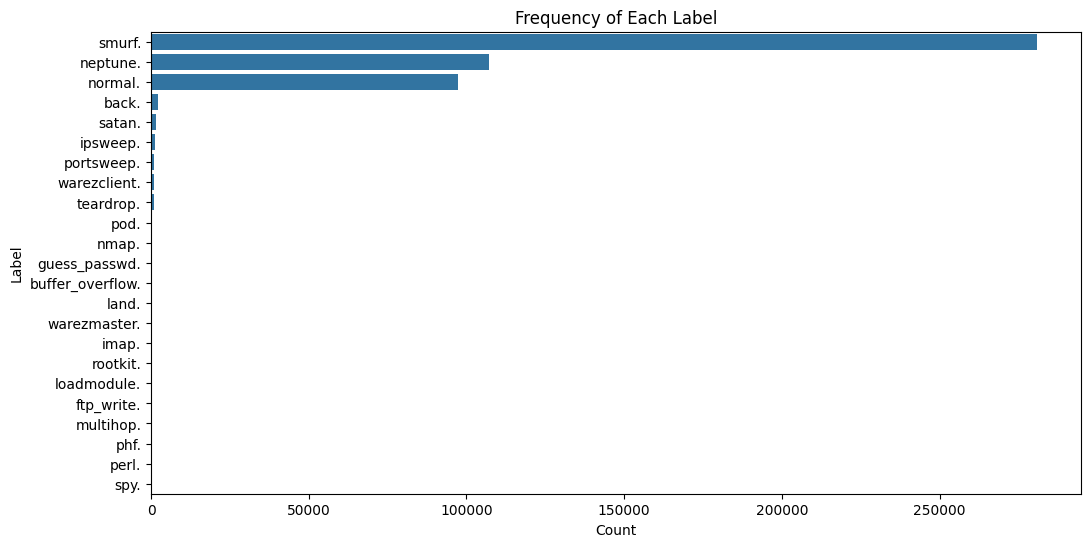

In [7]:
def plot_value_count(data):
    plt.figure(figsize=(12, 6))
    sns.countplot(data=data, y='label', order=data['label'].value_counts().index)
    plt.title('Frequency of Each Label')
    plt.xlabel('Count')
    plt.ylabel('Label')
    plt.show()

plot_value_count(data)

### All classes except "normal." in this dataset are considered attacks. They can be considered anomalies in our case.

Since our goal is to classify the network traffic as "normal" or "anomalous", we just need to convert the remaining classes into these two, and project this as a binary classification problem.

<font color='blue'>Convert all "normal" labels to a value "0", while all other labels to a value "1". Update the same "label" column in the "data" dataframe with the new values.</font>

In [8]:
data["label"] = data["label"].apply(lambda x: 0 if x == "normal." else 1)

Let's look at the label frequency now

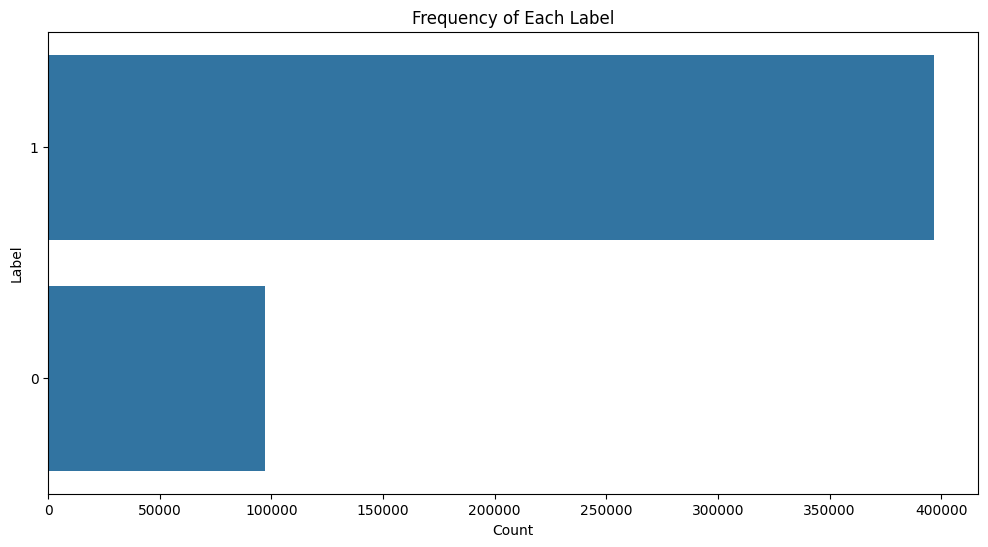

In [9]:
# the "label" column in the data df should contain the two labels "0" and "1" now.
plot_value_count(data)

Since we have the labels available for anomalous and non amomalous datapoints, this dataset is a good candidate for supervised anomaly detection.

Note that anomaly detection datasets usually have "less" anomalous data points than non-anomalous dataset, however, this is not the case in this dataset, even without binarizing the labels. Since, the dataset has **significant** number of anomalous datapoints, this also makes it a good candidate for Supervised Anomaly Detection.

## Splitting the dataset before Preprocessing

In [10]:
# Separate the labels from the features
X = data.drop("label", axis=1)
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Processing the Categorical Features

Let's look at the dataset description and figure out all the categorical features available in the dataset.





In [11]:
categorical_features = ["protocol_type", "service", "flag"]

<font color='blue'>Now convert the categorical features in One Hot representation. The code should update the X_train and X_test dataframes, with the one hot encoded features, and the original features dropped.</font>

In [12]:
# Initialize the OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical features for training data
X_train_categorical_encoded = encoder.fit_transform(X_train[categorical_features])

# Transform the categorical features for test data
X_test_categorical_encoded = encoder.transform(X_test[categorical_features])

# Create DataFrames with the one-hot encoded features
X_train_categorical_encoded_df = pd.DataFrame(X_train_categorical_encoded, columns=encoder.get_feature_names_out(categorical_features), index=X_train.index)
X_test_categorical_encoded_df = pd.DataFrame(X_test_categorical_encoded, columns=encoder.get_feature_names_out(categorical_features), index=X_test.index)

# Drop the original categorical features
X_train = X_train.drop(categorical_features, axis=1)
X_test = X_test.drop(categorical_features, axis=1)

# Concatenate the one-hot encoded features with the original datasets
X_train = pd.concat([X_train, X_train_categorical_encoded_df], axis=1)
X_test = pd.concat([X_test, X_test_categorical_encoded_df], axis=1)

Let's look at the new shape of our encoded dataset

In [13]:
print(X_train.shape)
print(X_test.shape)

(395216, 117)
(98805, 117)


## Normalizing the Continous Features

The continous (non-categorical) features in the KDD dataset have different scales. This can be a problem for our models. Let's normalize these features.

In [14]:
continuous_features = [x for x in column_names if x not in categorical_features and x !='label']
print('Total number of non-categorical features: ', len(continuous_features))

Total number of non-categorical features:  38


<font color='blue'>Write code to normalize the non categorical features in the dataset. The code should update X_train and X_test dataframes.</font>

In [15]:
# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the continuous features in X_train
X_train[continuous_features] = scaler.fit_transform(X_train[continuous_features])

# Transform the continuous features in X_test
X_test[continuous_features] = scaler.transform(X_test[continuous_features])

# Display the normalized datasets
display(X_train.head())
display(X_test.head())

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type_icmp,protocol_type_tcp,protocol_type_udp,service_IRC,service_X11,service_Z39_50,service_auth,service_bgp,service_courier,service_csnet_ns,service_ctf,service_daytime,service_discard,service_domain,service_domain_u,service_echo,service_eco_i,service_ecr_i,service_efs,service_exec,service_finger,service_ftp,service_ftp_data,service_gopher,service_hostnames,service_http,service_http_443,service_imap4,service_iso_tsap,service_klogin,service_kshell,service_ldap,service_link,service_login,service_mtp,service_name,service_netbios_dgm,service_netbios_ns,service_netbios_ssn,service_netstat,service_nnsp,service_nntp,service_ntp_u,service_other,service_pm_dump,service_pop_2,service_pop_3,service_printer,service_private,service_red_i,service_remote_job,service_rje,service_shell,service_smtp,service_sql_net,service_ssh,service_sunrpc,service_supdup,service_systat,service_telnet,service_tim_i,service_time,service_urh_i,service_urp_i,service_uucp,service_uucp_path,service_vmnet,service_whois,flag_OTH,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
133888,0.0,0.000001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,1.000000,0.0,0.0,0.0,0.0,1.00,0.00,0.0,1.000000,1.000000,1.00,0.00,1.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
67704,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.430528,0.019569,1.0,1.0,0.0,0.0,0.05,0.06,0.0,1.000000,0.039216,0.04,0.07,0.00,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
391027,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.577299,0.046967,1.0,1.0,0.0,0.0,0.08,0.05,0.0,1.000000,0.094118,0.09,0.05,0.00,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
372089,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001957,0.001957,0.0,0.0,1.0,1.0,1.00,0.00,0.0,0.031373,0.031373,1.00,0.00,0.12,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
460597,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.217221,0.013699,0.0,0.0,1.0,1.0,0.06,0.07,0.0,1.000000,0.027451,0.03,0.07,0.00,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type_icmp,protocol_type_tcp,protocol_type_udp,service_IRC,service_X11,service_Z39_50,service_auth,service_bgp,service_courier,service_csnet_ns,service_ctf,service_daytime,service_discard,service_domain,service_domain_u,service_echo,service_eco_i,service_ecr_i,service_efs,service_exec,service_finger,service_ftp,service_ftp_data,service_gopher,service_hostnames,service_http,service_http_443,service_imap4,service_iso_tsap,service_klogin,service_kshell,service_ldap,service_link,service_login,service_mtp,service_name,service_netbios_dgm,service_netbios_ns,service_netbios_ssn,service_netstat,service_nnsp,service_nntp,service_ntp_u,service_other,service_pm_dump,service_pop_2,service_pop_3,service_printer,service_private,service_red_i,service_remote_job,service_rje,service_shell,service_smtp,service_sql_net,service_ssh,service_sunrpc,service_supdup,service_systat,service_telnet,service_tim_i,service_time,service_urh_i,service_urp_i,service_uucp,service_uucp_path,service_vmnet,service_whois,flag_OTH,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
317921,0.0,1.488371e-06,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,1.000000,0.0,0.0,0.0,0.0,1.00,0.00,0.0,1.000000,1.000000,1.00,0.00,1.00,0.00,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
171422,0.0,1.488371e-06,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,1.000000,0.0,0.0,0.0,0.0,1.00,0.00,0.0,1.000000,1.000000,1.00,0.00,1.00,0.00,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
312181,0.0,1.488371e-06,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,1.000000,0.0,0.0,0.0,0.0,1.00,0.00,0.0,1.000000,1.000000,1.00,0.00,1.00,0.00,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
87346,0.0,4.975658e-07,0.001051,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.011742,0.011742,0.0,0.0,0.0,0.0,1.00,0.00,0.0,0.396078,1.000000,1.00,0.00,0.01,0.02,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
57449,0.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.508806,0.003914,1.0,1.0,0.0,0.0,0.01,0.06,0.0,1.000000,0.007843,0.01,0.07,0.00,0.00,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

# Modelling

## AutoEncoder

Now that the train and test data is ready. Let's design an AutoEncoder.

### Encoder

<font color='blue'>Design an Encoder. Take any aribitrary number of Dense Layers, with arbitrary number of neurons in each layer. The output dimensions should be significantly less than the number of dimensions in the Training Dataset. Feel free to try out various architectures here and use the one yeilding best results. The encoder should be an object of "Model" class</font>

In [16]:
# Define/Initialize the input dimension
input_dim = X_train.shape[1]

# Define the latent space dimension
latent_dim = 32 # You can experiment with different latent dimensions

# Define the layers of the Encoder
input_layer = layers.Input(shape=(input_dim,))
encoder_layer_1 = layers.Dense(128, activation='relu')(input_layer)
encoder_layer_2 = layers.Dense(64, activation='relu')(encoder_layer_1)
encoder_layer_3 = layers.Dense(32, activation='relu')(encoder_layer_2)
encoder_layer_4 = layers.Dense(16, activation='relu')(encoder_layer_3)
encoder_layer_5 = layers.Dense(latent_dim, activation='relu')(encoder_layer_4)


# Initialize the encoder Model using the above created architecture
encoder = Model(inputs=input_layer, outputs=encoder_layer_5)

# Print encoder summary
encoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 117)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        15,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,512 (103.56 KB)

 Trainable params: 26,512 (103.56 KB)

 Non-trainable params: 0 (0.00 B)

<font color='blue'>Design the decoder. The architecture of the Decoder should complement the Encoder. The decoder should be an object of "Model" class</font>

In [17]:
# Define the layers of the Decoder
decoder_layer_1 = layers.Dense(16, activation='relu')(encoder.output)
decoder_layer_2 = layers.Dense(32, activation='relu')(decoder_layer_1)
decoder_layer_3 = layers.Dense(64, activation='relu')(decoder_layer_2)
decoder_layer_4 = layers.Dense(128, activation='relu')(decoder_layer_3)
decoder_layer_5 = layers.Dense(input_dim, activation='sigmoid')(decoder_layer_4) # Output layer with sigmoid for normalization


# Initialize the Decoder Model using the above created architecture
decoder = Model(inputs=encoder.input, outputs=decoder_layer_5)

# Print decoder summary
decoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 117)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        15,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 117)            │        15,093 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,109 (207.46 KB)

 Trainable params: 53,109 (207.46 KB)

 Non-trainable params: 0 (0.00 B)

<font color='blue'>Combine encoder and decoder to produce the final model.</font>

In [18]:
# Combine encoder and decoder models to create the Autoencoder model
autoencoder = Model(inputs=encoder.input, outputs=decoder.output)

<font color='blue'>Compile and Train the AutoEncoder on X_train. Feel free to try out various hyperparameters, and/or try various hyperparameter search techniques.</font>

In [19]:
# Compile the autoencoder
autoencoder.compile(optimizer=Adam(), loss='mse')

# Train the autoencoder
history = autoencoder.fit(X_train, X_train,
                          epochs=50,
                          batch_size=256,
                          shuffle=True,
                          validation_data=(X_test, X_test))

Epoch 1/50
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 0.0273 - val_loss: 0.0045
Epoch 2/50
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0045 - val_loss: 0.0045
Epoch 3/50
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0045 - val_loss: 0.0045
Epoch 4/50
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0045 - val_loss: 0.0044
Epoch 5/50
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0045 - val_loss: 0.0043
Epoch 6/50
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0042 - val_loss: 0.0039
Epoch 7/50
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0039 - val_loss: 0.0039
Epoch 8/50
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0039 - val_loss: 0.0037
Epoch 9/50
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0033 - val_loss: 0.0017
Epoch 10/50
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0017 - val_loss: 0.0017
Epoch 11/50
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0015 - val_loss: 6.1622e-04
Epoch 12/50
1544/1544 

<font color='blue'>Create a plot to visualize the training and validation loss</font>

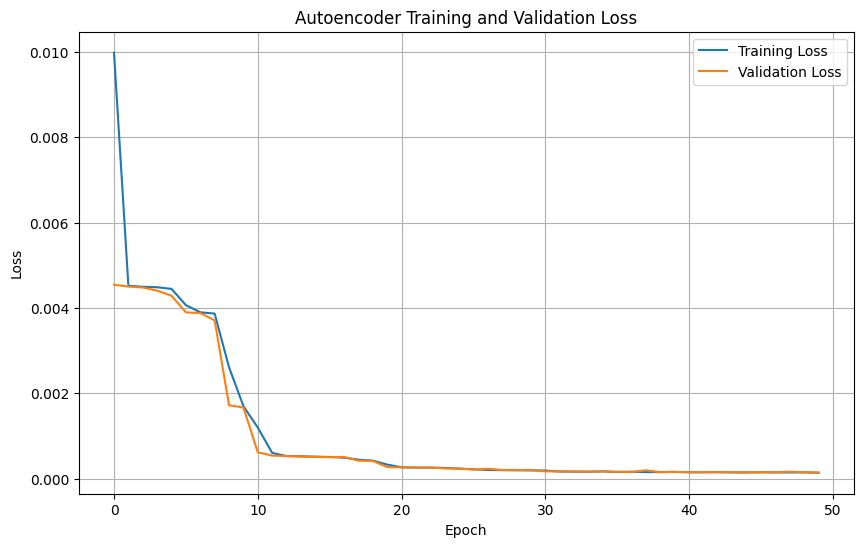

In [20]:
# Access the loss history
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot the training and validation loss curves
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Autoencoder Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Classifiers

The AutoEncoder can now give us a latent space from the Encoder, with the features representing the maximum information from the original set of 117 features. The task is to build a classifier, use this latent space from the AutoEncoder as input features to the classifier, and see if the classifier can predict network attacks accurately.

<font color='blue'> Build a classifier here. You are free to use any architecture i.e. non-neural models such as Logistic Regression, Decision Trees, Random Forest etc. or a Sequential Feed Forward Neural Network. </font>

### Classification using Feed Forward Neural Network



In [21]:
# Use the following function definition for the classifier. Feel free to add more hyperparameters to the function parameters, if needed.
def get_classifier(input_dimension, lr):
    model = models.Sequential([
        layers.Input(shape=(input_dimension,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(8, activation='relu'),
        layers.Dense(1, activation='sigmoid')  # Binary classification output
    ])
    optimizer = Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

### Classification on the non-autoencoded dataset

<font color='blue'>Train the classifier on the original data first - i.e. on X_train. You do not need to worry about the AutoEncoder's output in this exercise.</font>

In [38]:
# Get the classifier object using the above function defintion
classifier_raw = get_classifier(X_train.shape[1], 0.001)

# Train the classifier model on the raw features. Use X_test as validation data
history_raw = classifier_raw.fit(X_train, y_train,
                                 epochs=15,  # You can adjust the number of epochs
                                 batch_size=256, # You can adjust the batch size
                                 shuffle=True,
                                 validation_data=(X_test, y_test))

Epoch 1/15
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9881 - loss: 0.0928 - val_accuracy: 0.9990 - val_loss: 0.0039
Epoch 2/15
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9993 - loss: 0.0028 - val_accuracy: 0.9993 - val_loss: 0.0032
Epoch 3/15
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9994 - loss: 0.0024 - val_accuracy: 0.9993 - val_loss: 0.0029
Epoch 4/15
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9994 - loss: 0.0020 - val_accuracy: 0.9991 - val_loss: 0.0031
Epoch 5/15
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9994 - loss: 0.0020 - val_accuracy: 0.9994 - val_loss: 0.0027
Epoch 6/15
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9995 - loss: 0.0019 - val_accuracy: 0.9993 - val_loss: 0.0031
Epoch 7/15
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9995 - loss: 0.0019 - val_accuracy: 0.9994 - val_loss: 0.0024
Epoch 8/15
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9995 - loss: 0.0017 - 

<font color='blue'>Generate predictions on the X_test, Generate Classification Report and plot confusion matrix</font>

In [39]:
# Predict on the test set
y_pred_raw = (classifier_raw.predict(X_test) > 0.5).astype("int32")

# Evaluate the classifier by generating the classification report.
print("Classification Report (Raw Features):")
print(classification_report(y_test, y_pred_raw, digits=4))

3088/3088 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
Classification Report (Raw Features):
              precision    recall  f1-score   support

           0     0.9986    0.9991    0.9988     19353
           1     0.9998    0.9996    0.9997     79452

    accuracy                         0.9995     98805
   macro avg     0.9992    0.9994    0.9993     98805
weighted avg     0.9995    0.9995    0.9995     98805



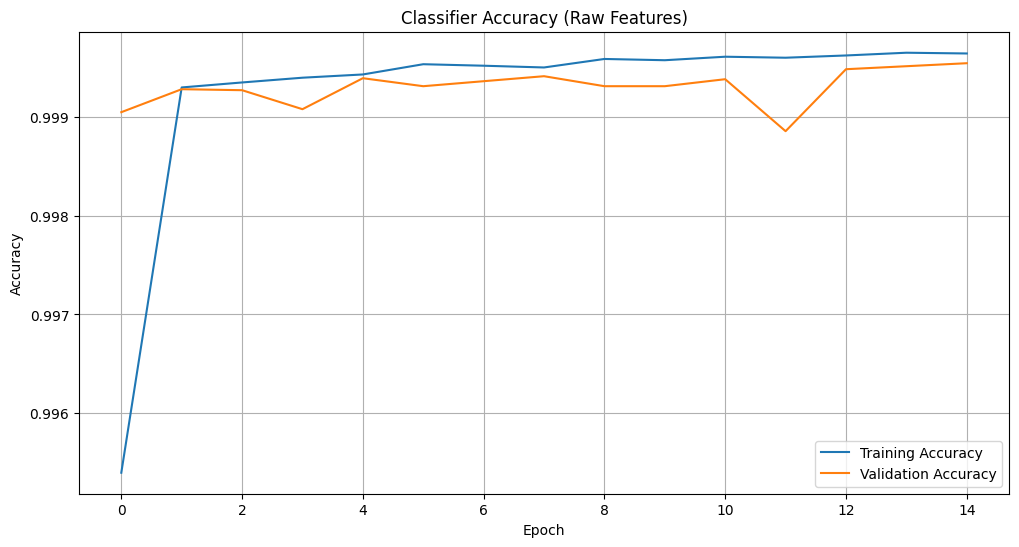

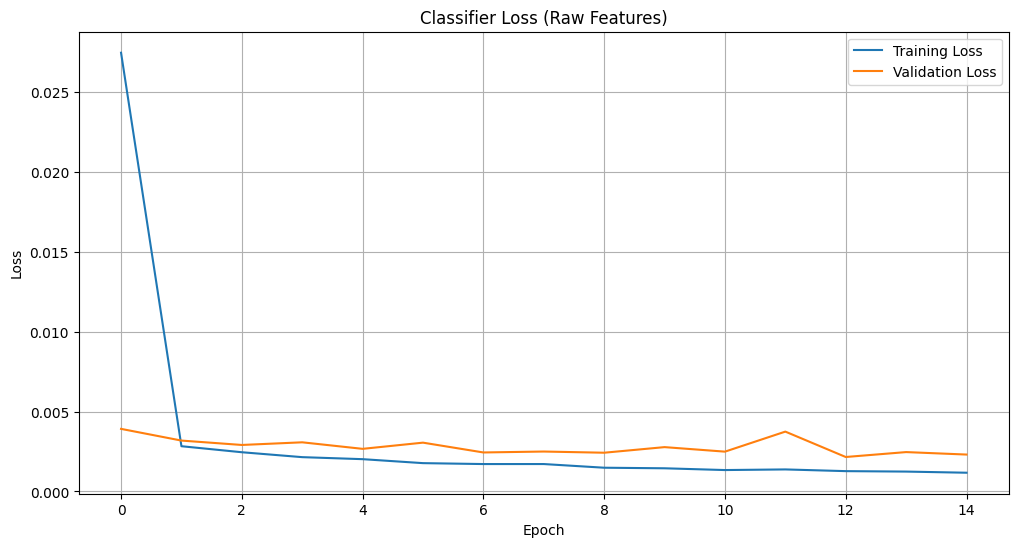

In [40]:
# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.plot(history_raw.history['accuracy'], label='Training Accuracy')
plt.plot(history_raw.history['val_accuracy'], label='Validation Accuracy')
plt.title('Classifier Accuracy (Raw Features)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history_raw.history['loss'], label='Training Loss')
plt.plot(history_raw.history['val_loss'], label='Validation Loss')
plt.title('Classifier Loss (Raw Features)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

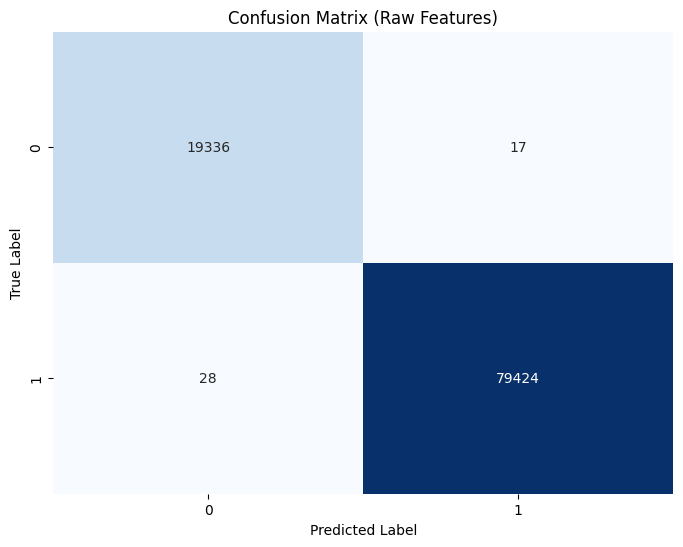

In [41]:
# Generate the confusion matrix
cm_raw = confusion_matrix(y_test, y_pred_raw)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Raw Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Classification on the Autoencoded dataset

<font color='blue'>Write code to generate latent representations for X_train and X_test from the Encoder component of the AutoEncoder</font>

In [26]:
# Obtain the encoded features on X_train
X_train_encoded = encoder.predict(X_train)

# Obtain the encoded features on X_test
X_test_encoded = encoder.predict(X_test)

12351/12351 ━━━━━━━━━━━━━━━━━━━━ 18s 1ms/step
3088/3088 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


<font color='blue'>Now train the classifier on these latent representations. You should try out various hyperparameters which your classifier can take in order to achieve the best performance.</font>

In [27]:
# Get the classifier object using the above function defintion
classifier_encoded = get_classifier(X_train_encoded.shape[1], 0.001)

# Train the classifier model on the encoded features obtained from the AutoEncoder. Use encoded features obtained for X_test as validation data.
history_encoded = classifier_encoded.fit(X_train_encoded, y_train,
                                         epochs=15, # You can adjust the number of epochs
                                         batch_size=256, # You can adjust the batch size
                                         shuffle=True,
                                         validation_data=(X_test_encoded, y_test))

Epoch 1/15
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9178 - loss: 0.4239 - val_accuracy: 0.9954 - val_loss: 0.0107
Epoch 2/15
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9969 - loss: 0.0087 - val_accuracy: 0.9968 - val_loss: 0.0090
Epoch 3/15
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9974 - loss: 0.0070 - val_accuracy: 0.9977 - val_loss: 0.0061
Epoch 4/15
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9979 - loss: 0.0057 - val_accuracy: 0.9977 - val_loss: 0.0066
Epoch 5/15
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9981 - loss: 0.0057 - val_accuracy: 0.9983 - val_loss: 0.0051
Epoch 6/15
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9983 - loss: 0.0050 - val_accuracy: 0.9984 - val_loss: 0.0047
Epoch 7/15
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9983 - loss: 0.0050 - val_accuracy: 0.9986 - val_loss: 0.0046
Epoch 8/15
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9985 - loss: 0.0044 -

<font color='blue'>Generate predictions on the X_test, Generate Classification Report and plot confusion matrix.</font>

In [28]:
# Predict on the test set
y_pred_encoded = (classifier_encoded.predict(X_test_encoded) > 0.5).astype("int32")

# Evaluate the classifier
print("Classification Report (Encoded Features):")
print(classification_report(y_test, y_pred_encoded, digits=4))

3088/3088 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
Classification Report (Encoded Features):
              precision    recall  f1-score   support

           0     0.9965    0.9984    0.9974     19353
           1     0.9996    0.9991    0.9994     79452

    accuracy                         0.9990     98805
   macro avg     0.9981    0.9988    0.9984     98805
weighted avg     0.9990    0.9990    0.9990     98805



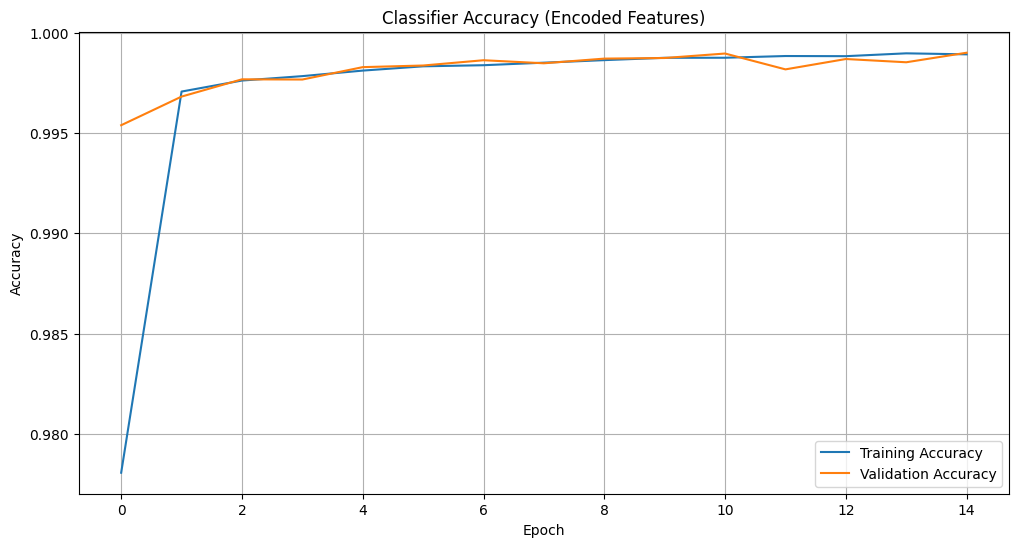

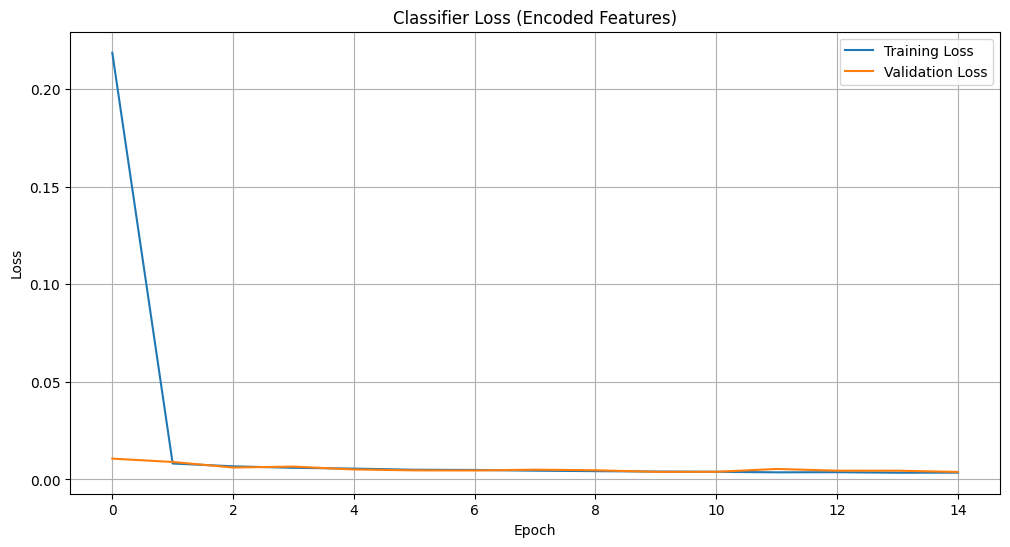

In [29]:
# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.plot(history_encoded.history['accuracy'], label='Training Accuracy')
plt.plot(history_encoded.history['val_accuracy'], label='Validation Accuracy')
plt.title('Classifier Accuracy (Encoded Features)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history_encoded.history['loss'], label='Training Loss')
plt.plot(history_encoded.history['val_loss'], label='Validation Loss')
plt.title('Classifier Loss (Encoded Features)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

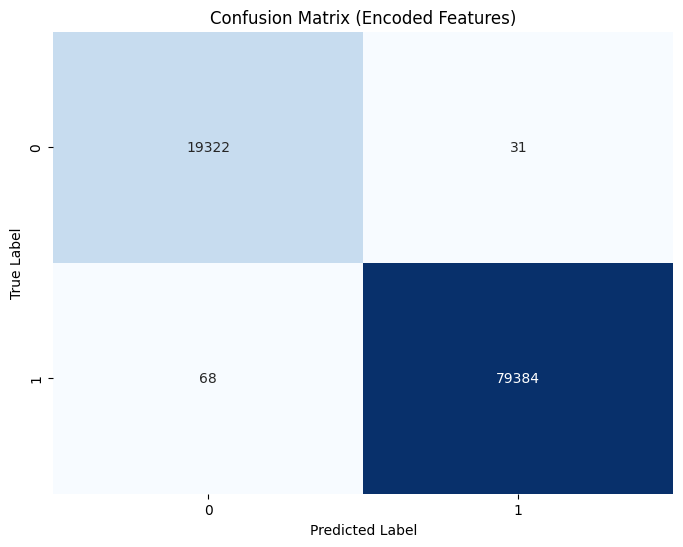

In [30]:
# Calculate the confusion matrix
cm_encoded = confusion_matrix(y_test, y_pred_encoded)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_encoded, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Encoded Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Classification using Vanilla Logistic Regression



### Classification on the non-autoencoded dataset

Train the classifier on the original data first - i.e. on X_train. You do not need to worry about the AutoEncoder's output in this exercise.

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize and train the Logistic Regression model on raw features
log_reg_raw = LogisticRegression(max_iter=1000)
log_reg_raw.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Generate predictions on the X_test, Generate Classification Report and plot confusion matrix

In [47]:
# Predict on the test set
y_pred_log_reg_raw = log_reg_raw.predict(X_test)

# Evaluate the Logistic Regression classifier
print("Classification Report (Logistic Regression - Raw Features):")
print(classification_report(y_test, y_pred_log_reg_raw))

Classification Report (Logistic Regression - Raw Features):
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     19353
           1       1.00      0.99      1.00     79452

    accuracy                           0.99     98805
   macro avg       0.99      0.99      0.99     98805
weighted avg       0.99      0.99      0.99     98805



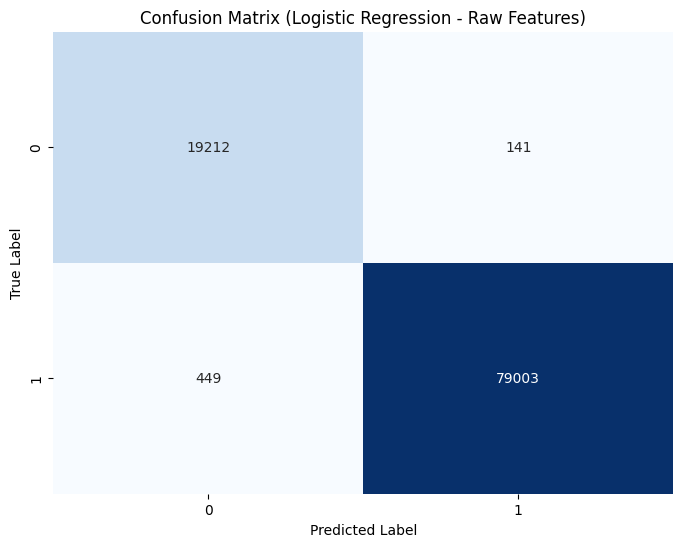

In [48]:
# Generate and plot the confusion matrix
cm_log_reg_raw = confusion_matrix(y_test, y_pred_log_reg_raw)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log_reg_raw, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Logistic Regression - Raw Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Classification on the Autoencoded dataset

Write code to generate latent representations for X_train and X_test from the Encoder component of the AutoEncoder

In [49]:
# Obtain the encoded features on X_train
X_train_encoded = encoder.predict(X_train)

# Obtain the encoded features on X_test
X_test_encoded = encoder.predict(X_test)

12351/12351 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step
3088/3088 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


Now train the classifier on these latent representations. You should try out various hyperparameters which your classifier can take in order to achieve the best performance.

In [50]:
# Initialize and train the Logistic Regression model on encoded features
log_reg_encoded = LogisticRegression(max_iter=1000)
log_reg_encoded.fit(X_train_encoded, y_train)

LogisticRegression(max_iter=1000)

Generate predictions on the X_test, Generate Classification Report and plot confusion matrix.

In [51]:
# Predict on the test set
y_pred_log_reg_encoded = log_reg_encoded.predict(X_test_encoded)

# Evaluate the Logistic Regression classifier
print("Classification Report (Logistic Regression - Encoded Features):")
print(classification_report(y_test, y_pred_log_reg_encoded))

Classification Report (Logistic Regression - Encoded Features):
              precision    recall  f1-score   support

           0       0.95      0.98      0.97     19353
           1       0.99      0.99      0.99     79452

    accuracy                           0.99     98805
   macro avg       0.97      0.98      0.98     98805
weighted avg       0.99      0.99      0.99     98805



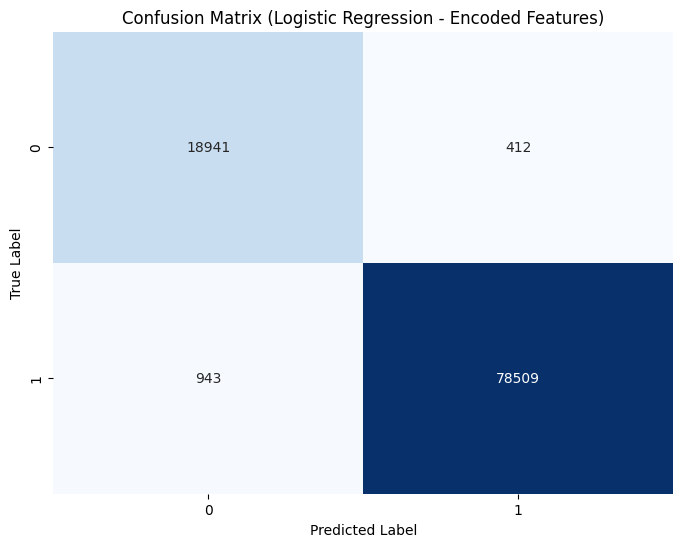

In [52]:
# Calculate the confusion matrix
cm_log_reg_encoded = confusion_matrix(y_test, y_pred_log_reg_encoded)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log_reg_encoded, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Logistic Regression - Encoded Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#Summary

<font color='blue'>Summarize your observations when training the classifiers on the Raw Features vs training it on the encoded features.

Compare and Summarize the results of the two approaches.</font>

For the NN Classifier, it had really high accuracy scores on both the raw and Autoencoded data; however, the False Positive and False Negative counts were a little higher on the NN Classifier that trained on the Encoded Features/ Representations form the Autoencoder vs the Raw Features.

For the Vanilla Logistic Regression Classifier, the False Positive and False Negative counts were higher on the model that trained on the Autoencoded Features as well.  

Overall, the NN Classifier had much better performance on the datasets than the Vanilla Logistic Classifier.  Furthermore, the Autoencoded features consistently performed worse than the Raw Features.
